# Trabajo Práctico Integrador Grupo 1

## EDA Vuelos Flybondi 2025 \(Bocanegra\)

El dataset a usar es un subconjunto de el dataset original Aterrizajes y despegues procesados por ANAC en el año 2025, en donde solo filtré por Aerolinea == Flybondi, para que la muestra no sea tan pesada y para poder centrar el análisis en una aerolínea en particular\.

### 1\. Carga de Librerías y Preparación de los Datos

Importamos las librerías necesarias para el manejo de datos \(pandas, numpy\) y para la visualización gráfica \(matplotlib, seaborn\)\.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1.1 Carga del dataset
df = pd.read_csv('vuelos_flybondi_2025.csv')

# Visualizamos las primeras filas para entender la estructura
df.head()

,Fecha UTC,Hora UTC,Clase de Vuelo (todos los vuelos),Clasificación Vuelo,Tipo de Movimiento,Aeropuerto,Origen / Destino,Aeronave,Pasajeros,PAX
0,01/01/2025,0:00,Regular,Doméstico,Aterrizaje,BAR,EZE,BO-737-8Q8,"167,00","83,50"
1,01/01/2025,0:07,Regular,Doméstico,Aterrizaje,CBA,BAR,BO-737-8U3,"83,00","41,50"
2,01/01/2025,0:20,Regular,Doméstico,Aterrizaje,EZE,JUJ,BO-737-8U3,"174,00","87,00"
3,01/01/2025,0:20,Regular,Doméstico,Despegue,BAR,EZE,BO-737-8Q8,"103,00","51,50"
4,01/01/2025,0:25,Regular,Doméstico,Aterrizaje,AER,POS,BO-737-86N,"170,00","85,00"


In [3]:
# 1.2 Inspección general de las variables (Tipos de datos)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43483 entries, 0 to 43482
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Fecha UTC                          43483 non-null  object
 1   Hora UTC                           43483 non-null  object
 2   Clase de Vuelo (todos los vuelos)  43483 non-null  object
 3   Clasificación Vuelo                43483 non-null  object
 4   Tipo de Movimiento                 43483 non-null  object
 5   Aeropuerto                         43483 non-null  object
 6   Origen / Destino                   43483 non-null  object
 7   Aeronave                           43483 non-null  object
 8   Pasajeros                          43483 non-null  object
 9   PAX                                43483 non-null  object
dtypes: object(10)
memory usage: 3.3+ MB


Limpieza y Transformación de Variables

Al observar la muestra de datos, notamos que columnas numéricas como Pasajeros y PAX fueron leídas como texto \(object\)\. Debemos transformarlas a formato flotante \(float\) para poder operar matemáticamente\.

También es clave convertir Fecha UTC al formato correcto de datetime\.

In [4]:
# Limpieza de caracteres (comillas y comas) y conversión a numérico
columnas_numericas = ['Pasajeros', 'PAX']

for col in columnas_numericas:
    if col in df.columns:
        # Convertimos todo a string por si hay formatos mixtos, borramos comillas, 
        # cambiamos comas por puntos y convertimos a float.
        df[col] = df[col].astype(str).str.replace('"', '', regex=False).str.replace(',', '.', regex=False)
        # Convertimos a numérico, transformando errores en NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Conversión de la columna Fecha a formato datetime
df['Fecha UTC'] = pd.to_datetime(df['Fecha UTC'], format='%d/%m/%Y', errors='coerce')

# Verificamos los cambios
df[['Fecha UTC', 'Pasajeros', 'PAX']].head()

,Fecha UTC,Pasajeros,PAX
0,2025-01-01,167.0,83.5
1,2025-01-01,83.0,41.5
2,2025-01-01,174.0,87.0
3,2025-01-01,103.0,51.5
4,2025-01-01,170.0,85.0


### 2\. Identificación de Datos Ausentes

Es crucial saber si la recolección de datos falló en algún punto o existen campos vacíos que puedan sesgar nuestro análisis\.

In [5]:
# Sumatoria de valores nulos por columna
valores_nulos = df.isnull().sum()

print("Cantidad de Valores Nulos por Columna:")
print(valores_nulos[valores_nulos > 0])

# Porcentaje respecto al total del DataFrame
print("\nPorcentaje de Nulos (%):")
porcentaje = (valores_nulos / len(df)) * 100
print(porcentaje[porcentaje > 0])

Cantidad de Valores Nulos por Columna:
Series([], dtype: int64)

Porcentaje de Nulos (%):
Series([], dtype: float64)


No hay valores nulos registrados\.

### 3\. Análisis Univariado y Detección de Outliers

Evaluamos la asimetría y el comportamiento de la variable más importante a nivel numérico: Pasajeros\. Utilizamos un histograma para ver la distribución y un Boxplot para identificar valores atípicos\.

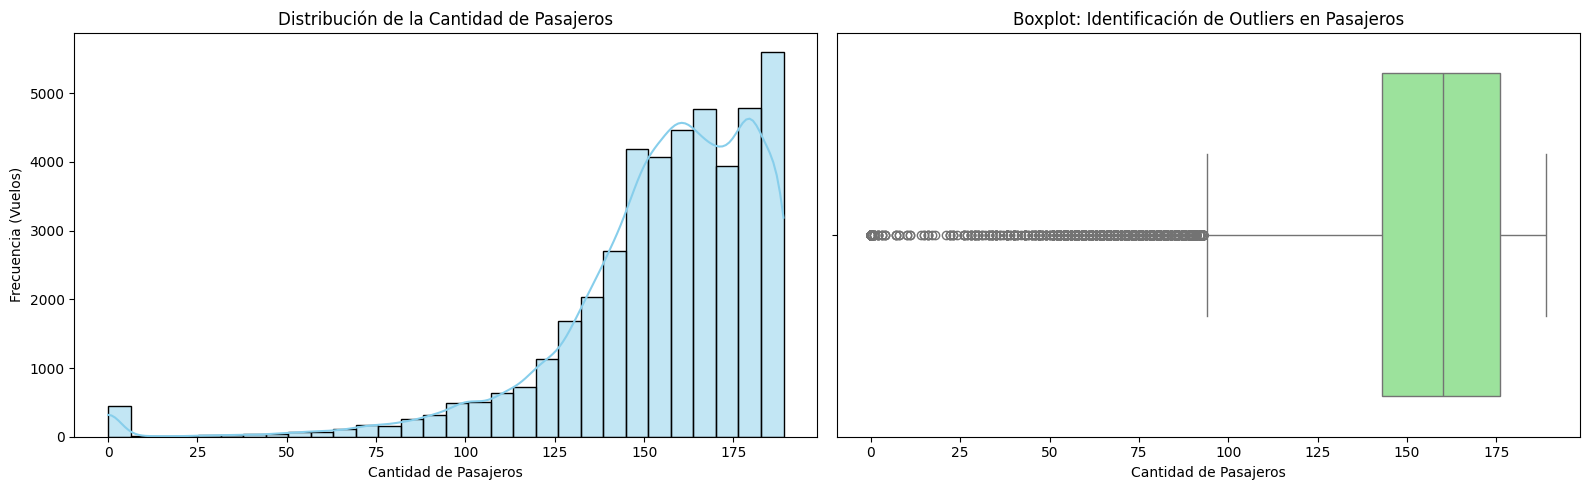

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Histograma
sns.histplot(df['Pasajeros'].dropna(), bins=30, kde=True, color='skyblue', ax=ax[0])
ax[0].set_title('Distribución de la Cantidad de Pasajeros')
ax[0].set_xlabel('Cantidad de Pasajeros')
ax[0].set_ylabel('Frecuencia (Vuelos)')

# Boxplot
sns.boxplot(x=df['Pasajeros'].dropna(), color='lightgreen', ax=ax[1])
ax[1].set_title('Boxplot: Identificación de Outliers en Pasajeros')
ax[1].set_xlabel('Cantidad de Pasajeros')

plt.tight_layout()
plt.show()

La distribución de pasajeros está fuertemente sesgada hacia la derecha: la mayoría de los vuelos concentran entre 150 y 190 pasajeros, lo que indica alta ocupación habitual\. Sin embargo, el boxplot revela una gran cantidad de outliers hacia la izquierda \(vuelos con muy pocos pasajeros, incluso cercanos a 0\), posiblemente vuelos técnicos, cancelaciones parciales o vuelos especiales\.

### 4\. Análisis de Variables Categóricas

Analizamos las categorías principales del negocio: Tipos de Movimientos \(Aterrizaje vs Despegue\) y el tráfico en los Aeropuertos\.

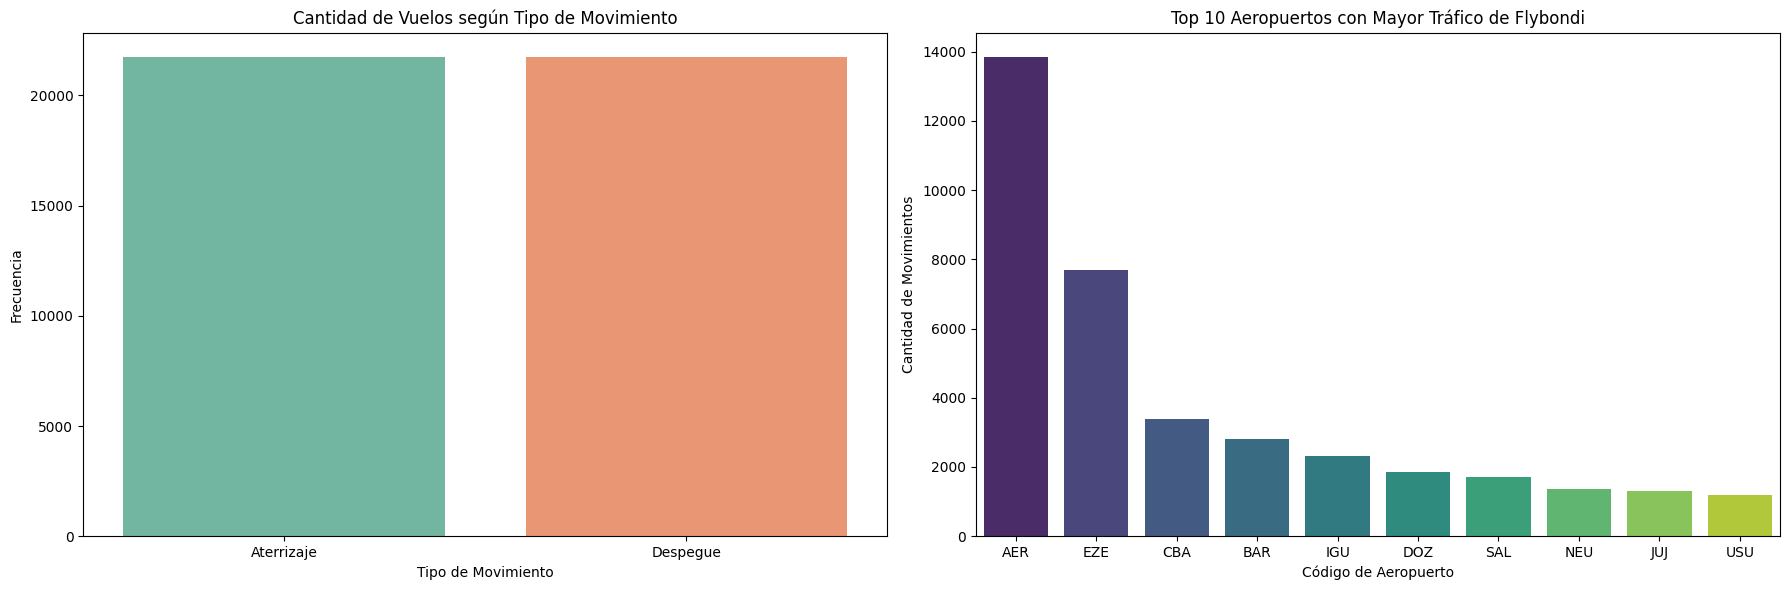

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Tipo de Movimiento
sns.countplot(data=df, x='Tipo de Movimiento', hue='Tipo de Movimiento', palette='Set2', ax=ax[0])
ax[0].set_title('Cantidad de Vuelos según Tipo de Movimiento')
ax[0].set_ylabel('Frecuencia')

# Top 10 Aeropuertos con mayor flujo
top_aeropuertos = df['Aeropuerto'].value_counts().head(10)
sns.barplot(x=top_aeropuertos.index, y=top_aeropuertos.values, hue=top_aeropuertos.index, palette='viridis', ax=ax[1])
ax[1].set_title('Top 10 Aeropuertos con Mayor Tráfico de Flybondi')
ax[1].set_xlabel('Código de Aeropuerto')
ax[1].set_ylabel('Cantidad de Movimientos')

plt.tight_layout()
plt.show()

Vemos que los tipos de movimientos están equilibrados, lo cual tiene sentido, por cada despegue hay un aterrizaje\. También notamos que los aeropuertos ubicados en Buenos Aires \(Aeroparque y Ezeiza\) concentran la mayor cantidad de vuelos, lo cual tiene lógica\.

### 5\. Análisis Temporal \(Evolución diaria\)

Utilizamos una serie de tiempo para entender cómo fluctúa la cantidad de operaciones \(vuelos\) a lo largo del año\.

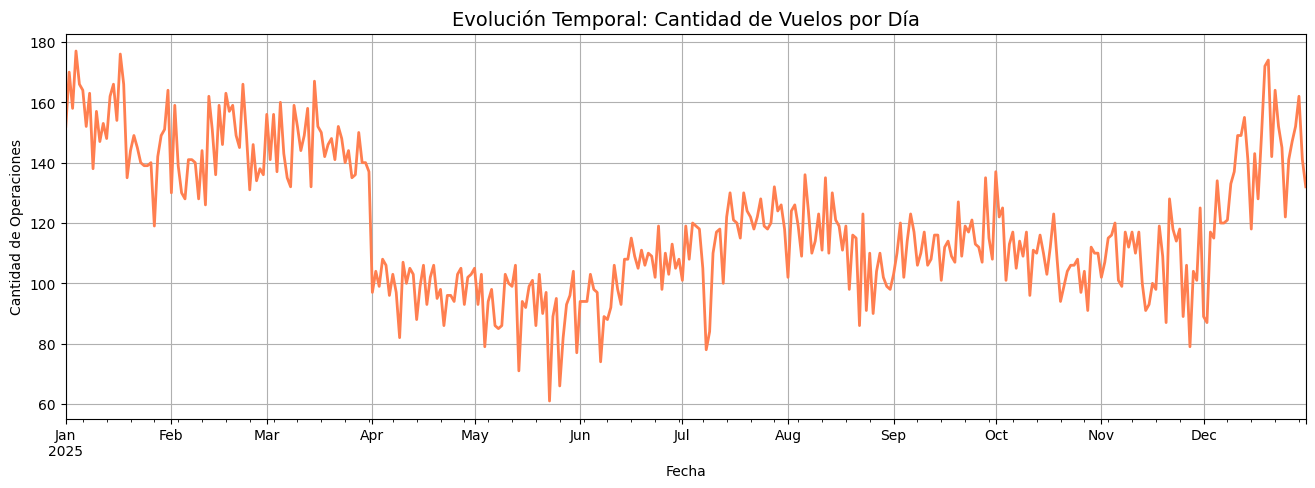

In [8]:
# Agrupamos la cantidad de registros (vuelos) por cada día
vuelos_por_dia = df.groupby('Fecha UTC').size()

plt.figure(figsize=(16, 5))
vuelos_por_dia.plot(color='coral', linewidth=2)
plt.title('Evolución Temporal: Cantidad de Vuelos por Día', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Operaciones')
plt.grid(True)
plt.show()

Se observa una caída abrupta en abril\-junio 2025, donde los vuelos diarios bajaron de ~150\-175 a un piso de ~65 operaciones\. Podría corresponder a una temporada baja, reducción de rutas o un evento disruptivo\. A partir de julio la actividad se recupera progresivamente, con un repunte notable en diciembre, consistente con la temporada alta de verano en Argentina\.

### 6\. Análisis de correlación

Finalmente, evaluamos si existe correlación matemática entre las variables numéricas\.

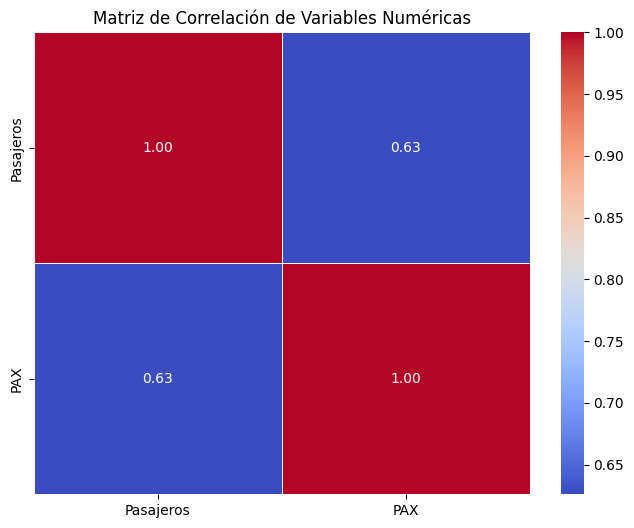

In [9]:
# Filtramos solo columnas numéricas
num_cols = df.select_dtypes(include=['float64', 'int64'])

# Calculamos la matriz de correlación
corr_matrix = num_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

La matriz solo contiene dos variables numéricas \(Pasajeros y PAX\) con una correlación de 0\.63, moderada\-alta\. Esto confirma que PAX es una variable derivada de Pasajeros pero no idéntica\. 

Al analizar la descripción del campo en la web oficial vemos que dice lo siguiente: 1pax=1tarjeta de embarque\. Usar esta columna al analizar la cantidad de pasajeros cabotaje a nivel total país\. Al analizar los pasajeros internacionales es indiferente usar esta columna o la anterior\.

O sea, que para vuelos internacionales es exactamente el mismo valor para PAX que para Pasajeros, y en los nacionales es exactamente la mitad\. Conclusión: son linealmente dependientes, podríamos prescindir de una variable\. Me quedaría con Pasajeros que es la más estándar\.

### 7\. Conclusiones del EDA

Con este Análisis Exploratorio de Datos inicial pudimos:

- Transformar tipos de datos para que fueran manipulables estadísticamente\.

- Entender el rango, promedio y casos atípicos en la ocupación de pasajeros por vuelo\.

- Visualizar la centralización del tráfico por código de aeropuerto\.

- Observar la tendencia temporal de los vuelos de Flybondi durante la muestra de 2025\.

- Descubrir que hay una fuerte correlación entre las variables numéricas\.

## EDA: Recorridos Ecobici 2024 \(Hurtado\)

### 1\.Carga de librerías y preparación de los datos para hacerlos accesibles

En esta etapa importamos las librerías a utilizar para que el sistema entienda qué estamos analizando\. Como el dataset es muy grande \(más de 3,5 millones de filas\), usamos una muestra para que el procesamiento sea fluido\.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
# Cargamos el dataset y lo exploramos
df_bicis = pd.read_csv('badata_ecobici_recorridos_realizados_2024.csv')

df_bicis.head()

,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
0,20428222,568,2024-01-23 18:36:00,513,308 - SAN MARTIN II,Av. San Martín 5129,-58.490739,-34.597130,2024-01-23 18:45:28,498,055 - HABANA,Gral. José Gervasio Artigas 4298 (y Habana),-58.494959,-34.586598,992557.0,FIT,MALE
1,20431744,1355,2024-01-23 22:41:20,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,2024-01-23 23:03:55,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,320782.0,FIT,FEMALE
2,20429936,0,2024-01-23 20:06:22,467,328 - SARMIENTO II,Sarmiento 2037,-58.395893,-34.605514,2024-01-23 20:06:22,6,006 - Parque Lezama,"Avenida Martin Garcia, 295",-58.369758,-34.628526,828678.0,FIT,FEMALE
3,20429976,0,2024-01-23 20:08:17,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,2024-01-23 20:08:17,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,320782.0,ICONIC,FEMALE
4,20424802,680,2024-01-23 15:18:39,137,137 - AZOPARDO Y CHILE,AZOPARDO 700,-58.367492,-34.615598,2024-01-23 15:29:59,150,150 - RODRIGO BUENO,Av. España 2200,-58.355465,-34.618755,861425.0,FIT,FEMALE


In [12]:
# Averiguamos el tipo de variables que contiene el dataset

df_bicis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3559284 entries, 0 to 3559283
Data columns (total 17 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   id_recorrido                int64  
 1   duracion_recorrido          int64  
 2   fecha_origen_recorrido      object 
 3   id_estacion_origen          int64  
 4   nombre_estacion_origen      object 
 5   direccion_estacion_origen   object 
 6   long_estacion_origen        float64
 7   lat_estacion_origen         float64
 8   fecha_destino_recorrido     object 
 9   id_estacion_destino         int64  
 10  nombre_estacion_destino     object 
 11  direccion_estacion_destino  object 
 12  long_estacion_destino       float64
 13  lat_estacion_destino        float64
 14  id_usuario                  float64
 15  modelo_bicicleta            object 
 16  genero                      object 
dtypes: float64(5), int64(4), object(8)
memory usage: 461.6+ MB


In [13]:
#Tomamos una muestra del 1% para trabajar más rápido
df = df_bicis.sample(frac=0.01, random_state=42)

In [14]:
# Chequeamos el tamaño del nuevo dataset y tipos de datos
print(df.shape)
print(df.dtypes)

(35593, 17)
id_recorrido                    int64
duracion_recorrido              int64
fecha_origen_recorrido         object
id_estacion_origen              int64
nombre_estacion_origen         object
direccion_estacion_origen      object
long_estacion_origen          float64
lat_estacion_origen           float64
fecha_destino_recorrido        object
id_estacion_destino             int64
nombre_estacion_destino        object
direccion_estacion_destino     object
long_estacion_destino         float64
lat_estacion_destino          float64
id_usuario                    float64
modelo_bicicleta               object
genero                         object
dtype: object


In [15]:
#Vemos la cantidad de valores nulos en cada columna
print(df.isnull().sum())

id_recorrido                    0
duracion_recorrido              0
fecha_origen_recorrido          0
id_estacion_origen              0
nombre_estacion_origen          0
direccion_estacion_origen       0
long_estacion_origen            0
lat_estacion_origen             0
fecha_destino_recorrido        35
id_estacion_destino             0
nombre_estacion_destino         0
direccion_estacion_destino      0
long_estacion_destino           0
lat_estacion_destino            0
id_usuario                      0
modelo_bicicleta                0
genero                        114
dtype: int64


### 2\. Limpieza y transformación

Ya que se encuentran fechas como object y nulos en género y necesitamos preparar los datos para su posterior análisis\.

In [16]:
# Convertimos las fechas a tipo datetime (texto a fecha)
df['fecha_origen_recorrido'] = pd.to_datetime(df['fecha_origen_recorrido'])
df['fecha_destino_recorrido'] = pd.to_datetime(df['fecha_destino_recorrido'])

# Eliminamos los nulos
df.dropna(subset=['genero', 'fecha_destino_recorrido'], inplace=True)

# Filtramos errores para que la duración sea mayor a 0
df = df[df['duracion_recorrido'] > 0 ]

In [17]:
# Chequeamos que no haya nulos en las columnas limpiadas
print("valores nulos después de la limpieza:")
print(df[['genero', 'fecha_destino_recorrido']].isnull().sum())

# Verificamos que las fechas ahora sean datetime y no object
print("\nTipos de datos actualizados:")
print(df[['fecha_origen_recorrido', 'fecha_destino_recorrido']].dtypes)

valores nulos después de la limpieza:
genero                     0
fecha_destino_recorrido    0
dtype: int64

Tipos de datos actualizados:
fecha_origen_recorrido     datetime64[ns]
fecha_destino_recorrido    datetime64[ns]
dtype: object


### 3\. Análisis estadístico y visual

En esta etapa hacemos un análisis de naturaleza y outliers\.

In [18]:
#Visualizamos las estadísticas básicas y limitamos los decimales a 2 para que no sea tan largo
print(df['duracion_recorrido'].describe().round(2))

count      35139.00
mean        1263.88
std         7432.73
min            1.00
25%          505.50
50%          892.00
75%         1474.00
max      1231234.00
Name: duracion_recorrido, dtype: float64


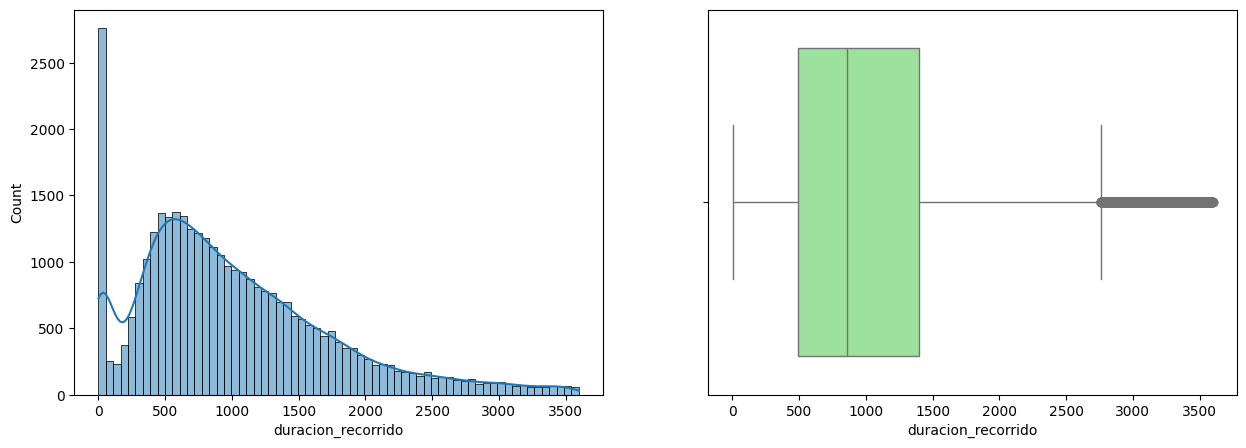

In [19]:
# Gráficos Histograma y Outliers
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Filtramos a menos de 1 hora (3600 segundos) para que el gráfico sea entendible
df_grafico = df[df['duracion_recorrido'] < 3600]

sns.histplot(df_grafico['duracion_recorrido'], kde=True, ax=ax[0])
sns.boxplot(x=df_grafico['duracion_recorrido'], ax=ax[1], color='lightgreen')
plt.show()


Como el gráfico muestra muchos valores con tiempo menores a 1 o 2 minutos, procedemos a filtrarlos y ajustamos el límite del eje Y manualmente\. 

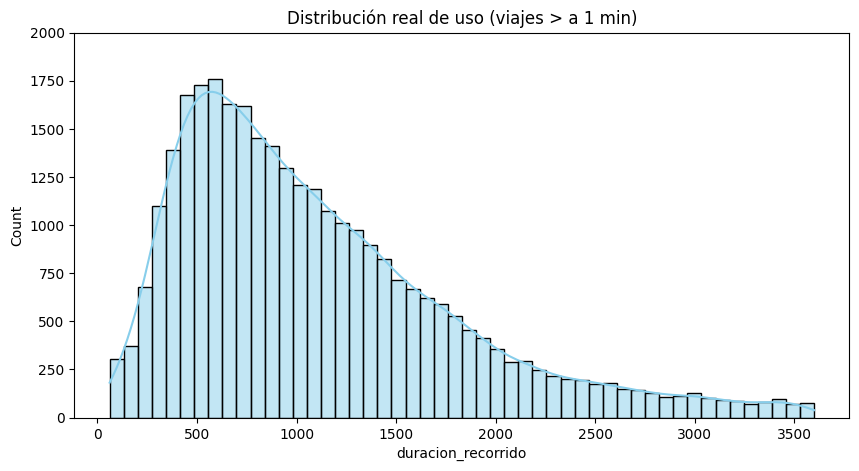

In [20]:
# Filtramos las duraciones de recorridos menores a 60 segundos y limitamos a 1 hora (3600 segundos)
df_zoom = df[(df['duracion_recorrido'] > 60 ) & (df['duracion_recorrido'] <3600)]

plt.figure(figsize=(10,5))

# Aumentamos los bins (subdivisiones del histograma) a 50 para ver más detalle
sns.histplot(data=df_zoom, x='duracion_recorrido', bins=50, kde=True, color='skyblue')

# Bajamos el límite del eje Y a 2000 para mejor visualización de la curva
plt.ylim(0, 2000)

# Le agregamos título al gráfico
plt.title('Distribución real de uso (viajes > a 1 min)')
plt.show()

### Análisis de uso

Comparamos qué modelo de bici es más usado

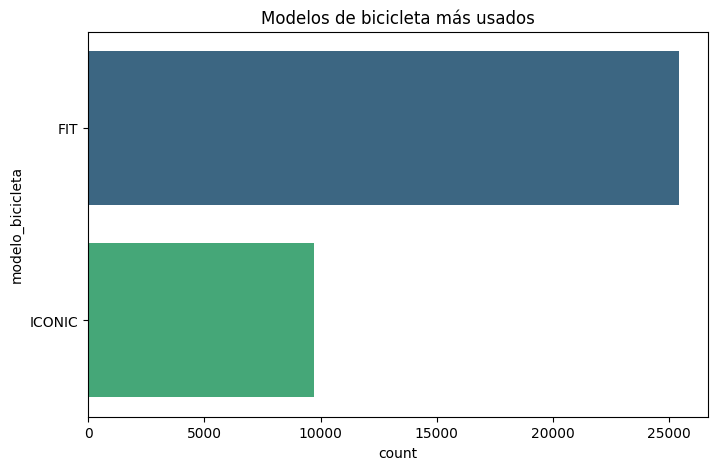

In [21]:
# Contamos la frecuencia de cada modelo de bici
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    y='modelo_bicicleta',
    hue='modelo_bicicleta',
    palette='viridis',
    order=df['modelo_bicicleta'].value_counts().index,
    legend=False
) 
plt.title('Modelos de bicicleta más usados')
plt.show()

### Análisis de duración vs género

Comparamos el género \(variable cualitativa\) con la duración de los viajes \(variable cuantitativa\)\.

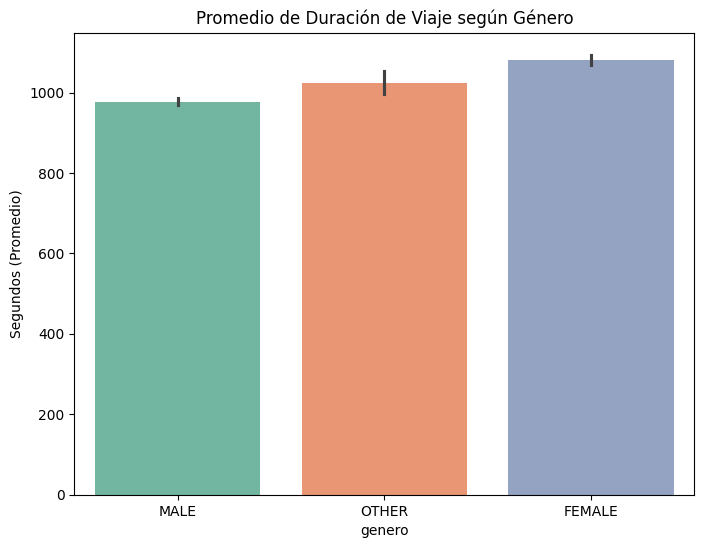

In [22]:
# Comparación de duración: Género vs Duración
plt.figure(figsize=(8,6))
sns.barplot(
    data=df[df['duracion_recorrido'] < 3600], 
    x='genero', 
    y='duracion_recorrido', 
    hue='genero', # Corregimos el aviso de palette
    palette='Set2', 
    legend=False
)
plt.title('Promedio de Duración de Viaje según Género')
plt.ylabel('Segundos (Promedio)')
plt.show()

### 4\. Análisis de correlación

Evaluamos si existe una relación entre la hora del día en que se inicia el viaje con la duración del recorrido

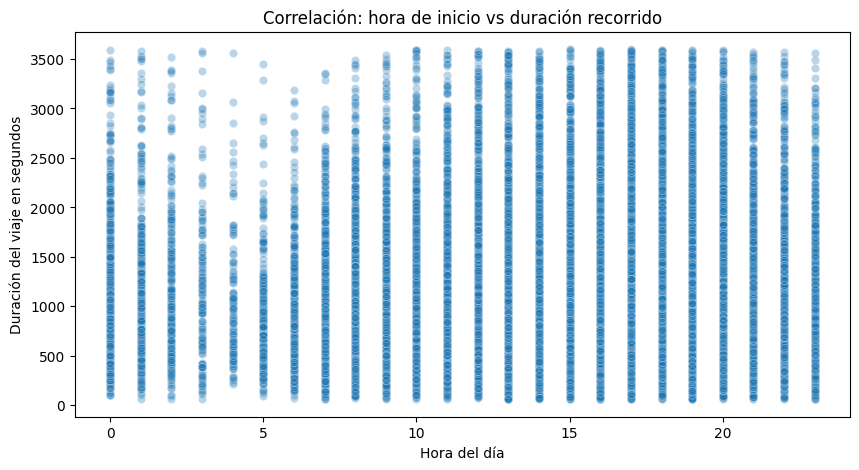

In [23]:
# Creamos la variable hora de inicio
df['hora_inicio'] = df['fecha_origen_recorrido'].dt.hour

# Filtramos para mejor visualización (viajes entre 1 minuto y 1 hora)
df_zoom = df[(df['duracion_recorrido'] > 60 )&
 (df['duracion_recorrido'] < 3600) ]

#Hacemos un Scatterplot: hora de inicio vs duración
plt.figure(figsize=(10,5))
sns.scatterplot(data=df_zoom, x='hora_inicio', y='duracion_recorrido', alpha=0.3)
plt.title('Correlación: hora de inicio vs duración recorrido')
plt.xlabel('Hora del día')
plt.ylabel('Duración del viaje en segundos')
plt.show()

### 5\. Conclusiones finales

A partir del EDA realizado sobre el dataset Recorridos de Ecobici 2024, podemos extraer las siguientes conclusiones:

### 1\. Uso del servicio

El servicio registra muchos viajes de corta duración, concentrándose la mayoría entre los 10 y 25 minutos\. Lo que confirma que el uso principal es para viajes cercanos y no para moverse por toda la ciudad\.

### 2\. Preferencia de modelo de bici

El modelo de bicicleta FIT es el más usado por los usuarios, superando el modelo ICONIC\. De todas maneras, este es un punto que solamente brinda el dataset, ya que los usuarios, por lo general, no tienen acceso a elegir el tipo de bici\.

### 3\. Perspectiva de género

No se observan diferencias significativas en la duración de los viajes entre los distintos géneros registrados\.

### 4\. Análisis de correlación

El gráfico de dispersión scatterplot entre la hora de inicio y la duración del viaje muestra que no existe una correlación fuerte entre las variables\. Indicando que a cualquier hora del día se realizan viajes de diversas duraciones, y la hora no es un factor que determine por sí solo cuánto tiempo se usará la bici\.

## TPI: EDA \- Franco Arnaudin

El siguiente análisis exploratorio de datos está hecho sobre una base de siniestros viales provista por el observatorio vial de la provincia de Santa Fe, que es el área oficial encargada de producir estadísticas en materia de siniestralidad vial con lesionados y fallecidos en esa provincia\.

In [24]:
import pandas as pd
# Carga inicial de los datos
accidents_df = pd.read_csv('siniestros-viales-2021.csv')

### Estructura y tipos de datos

In [25]:
accidents_df.shape

(10581, 41)

In [26]:
accidents_df.dtypes

anio_acci                    int64
nro_acci                     int64
fecha                       object
desc_dia                    object
hora_aprox                  object
desc_ruta                   object
km                         float64
cant_participantes           int64
desc_participante           object
calle_avenida_km            object
total                        int64
heridos_leves                int64
heridos_graves               int64
heridos_gravisimos           int64
ilesos                       int64
fallecidos                   int64
sin_datos                    int64
posicion_XY                 object
desc_tipo_via               object
desc_ruta_ori               object
desc_loc                    object
desc_dpto                   object
desc_tipo_calzada           object
desc_tipo_banquina          object
desc_unidad_regional        object
desc_lugar_calzada          object
desc_zona                   object
desc_prioridad              object
desc_estado_semaforo

### Vistazo rápido de los datos

In [27]:
accidents_df.head(10 )

,anio_acci,nro_acci,fecha,desc_dia,hora_aprox,desc_ruta,km,cant_participantes,desc_participante,calle_avenida_km,...,desc_estado_visibilidad,desc_luminosidad,desc_estado_clima,desc_tipo_colision,desc_tipo_atropello,desc_tipo_hecho,desc_pres_calzada,desc_senializacion,desc_separacion_via,desc_restriccion
0,2021,1,2021-01-15,Viernes,18:40:00,NaN,0.0,2,"Moto/Ciclomotor,Automóvil",Centeno Y Constitución,...,Buena,Diurna,Buen Tiempo,S/D,S/D,Colisión,Ninguna,Faltante,Ninguna,Sin restricción
1,2021,2,2021-01-13,Miercoles,13:10:00,NaN,0.0,2,"Moto/Ciclomotor,Moto/Ciclomotor",Vera Mujica Y Dr. Rivas,...,Buena,Diurna,Buen Tiempo,De alcance,S/D,Colisión,Ninguna,Faltante,Ninguna,Sin restricción
2,2021,3,2021-01-14,Jueves,00:50:00,NaN,0.0,2,"Moto/Ciclomotor,Pickup/Utilitario",Av. Battle y Ordoñez Y Santiago,...,Reducida,Nocturna,Buen Tiempo,Lateral,S/D,Colisión,Ninguna,Faltante,Ninguna,Sin restricción
3,2021,4,2021-01-12,Martes,14:10:00,NaN,0.0,2,"Moto/Ciclomotor,Automóvil",Pje. Suriguez y Acha,...,Buena,Diurna,Buen Tiempo,Frontal,S/D,Colisión,Ninguna,Faltante,Ninguna,Sin restricción
4,2021,5,2021-01-11,Lunes,18:00:00,NaN,0.0,2,"Peatón,Moto/Ciclomotor",Bv. Oroño,...,Buena,Diurna,Buen Tiempo,S/D,Peatón,Colisión,Ninguna,Vertical,Cordón divisorio,Sin restricción
5,2021,7,2021-01-13,Miercoles,18:00:00,NaN,0.0,2,"Moto/Ciclomotor,Automóvil",Bv. Oroño Y Rueda,...,S/D,Diurna,Buen Tiempo,Lateral,S/D,Colisión,Ninguna,S/D,"Cordón divisorio,Vegetación",Sin restricción
6,2021,8,2021-01-09,Sabado,NaN,NaN,0.0,2,"Moto/Ciclomotor,Moto/Ciclomotor",Benito Juárez Y Pje. Medici,...,Buena,Diurna,Buen Tiempo,Otro,S/D,Colisión,Ninguna,Faltante,Ninguna,Sin restricción
7,2021,9,2021-01-15,Viernes,11:30:00,NaN,0.0,3,"Moto/Ciclomotor,Automóvil,Automóvil",Av. Uriburu Y Buenos Aires,...,Buena,Diurna,Buen Tiempo,Múltiple,S/D,Colisión,Ninguna,"Horizontal,Vertical",Cordón divisorio,Sin restricción
8,2021,11,2021-01-15,Viernes,14:30:00,NaN,0.0,2,"Bicicleta,Moto/Ciclomotor",San Martin Y Pte. Quintana,...,Buena,Diurna,Buen Tiempo,S/D,Ciclista,Colisión,Ninguna,"Horizontal,Vertical",Cordón divisorio,Sin restricción
9,2021,12,2021-01-12,Martes,11:25:00,NaN,0.0,2,"Automóvil,Moto/Ciclomotor",Buenos Aires Y Pje. 525,...,Buena,Diurna,Buen Tiempo,Lateral,S/D,Colisión,Ninguna,S/D,Cordón divisorio,Sin restricción


### Descripción general del conjunto de datos

In [28]:
accidents_df.describe()

,anio_acci,nro_acci,km,cant_participantes,total,heridos_leves,heridos_graves,heridos_gravisimos,ilesos,fallecidos,sin_datos
count,10581.0,10581.000000,10581.000000,10581.000000,10581.000000,10581.000000,10581.000000,10581.000000,10581.000000,10581.000000,10581.000000
mean,2021.0,5358.441641,16.756119,1.757868,2.173141,1.118042,0.137889,0.004347,0.790663,0.043096,0.079104
std,0.0,3088.194394,87.858472,0.487428,1.292292,0.752662,0.390073,0.072623,1.122519,0.226410,0.318133
min,2021.0,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2021.0,2690.000000,0.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2021.0,5361.000000,0.000000,2.000000,2.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,2021.0,8037.000000,0.000000,2.000000,2.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,2021.0,10696.000000,937.000000,6.000000,61.000000,13.000000,5.000000,3.000000,60.000000,4.000000,4.000000


In [29]:
accidents_df.describe().T

,count,mean,std,min,25%,50%,75%,max
anio_acci,10581.0,2021.000000,0.000000,2021.0,2021.0,2021.0,2021.0,2021.0
nro_acci,10581.0,5358.441641,3088.194394,1.0,2690.0,5361.0,8037.0,10696.0
km,10581.0,16.756119,87.858472,0.0,0.0,0.0,0.0,937.0
cant_participantes,10581.0,1.757868,0.487428,1.0,1.0,2.0,2.0,6.0
total,10581.0,2.173141,1.292292,1.0,2.0,2.0,2.0,61.0
heridos_leves,10581.0,1.118042,0.752662,0.0,1.0,1.0,1.0,13.0
heridos_graves,10581.0,0.137889,0.390073,0.0,0.0,0.0,0.0,5.0
heridos_gravisimos,10581.0,0.004347,0.072623,0.0,0.0,0.0,0.0,3.0
ilesos,10581.0,0.790663,1.122519,0.0,0.0,1.0,1.0,60.0
fallecidos,10581.0,0.043096,0.226410,0.0,0.0,0.0,0.0,4.0


In [30]:
accidents_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10581 entries, 0 to 10580
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   anio_acci                10581 non-null  int64  
 1   nro_acci                 10581 non-null  int64  
 2   fecha                    10581 non-null  object 
 3   desc_dia                 10581 non-null  object 
 4   hora_aprox               9104 non-null   object 
 5   desc_ruta                2115 non-null   object 
 6   km                       10581 non-null  float64
 7   cant_participantes       10581 non-null  int64  
 8   desc_participante        10581 non-null  object 
 9   calle_avenida_km         10581 non-null  object 
 10  total                    10581 non-null  int64  
 11  heridos_leves            10581 non-null  int64  
 12  heridos_graves           10581 non-null  int64  
 13  heridos_gravisimos       10581 non-null  int64  
 14  ilesos                

### Análisis de nulos

In [31]:
 accidents_df.isnull().sum()

anio_acci                     0
nro_acci                      0
fecha                         0
desc_dia                      0
hora_aprox                 1477
desc_ruta                  8466
km                            0
cant_participantes            0
desc_participante             0
calle_avenida_km              0
total                         0
heridos_leves                 0
heridos_graves                0
heridos_gravisimos            0
ilesos                        0
fallecidos                    0
sin_datos                     0
posicion_XY                 173
desc_tipo_via                 0
desc_ruta_ori              8465
desc_loc                      0
desc_dpto                     0
desc_tipo_calzada             0
desc_tipo_banquina            0
desc_unidad_regional          0
desc_lugar_calzada            0
desc_zona                     0
desc_prioridad                0
desc_estado_semaforo          0
desc_lugar_via                0
desc_estado_via               0
desc_est

### Visualización de datos

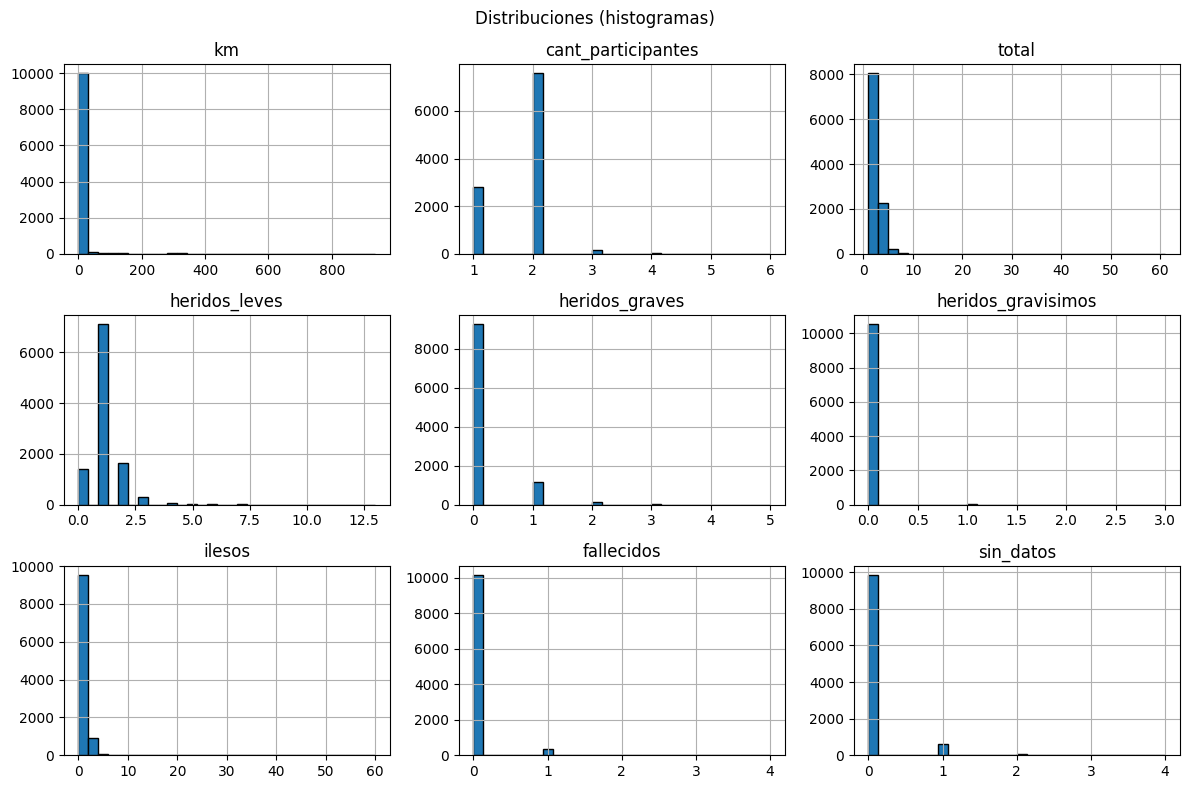

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = [
    "km","cant_participantes","total",
    "heridos_leves","heridos_graves","heridos_gravisimos",
    "ilesos","fallecidos","sin_datos"
]

accidents_df[num_cols].hist(bins=30, figsize=(12,8), edgecolor="black")
plt.suptitle("Distribuciones (histogramas)")
plt.tight_layout()
plt.show()

### Distribución de accidentes por el tipo de asfaltado

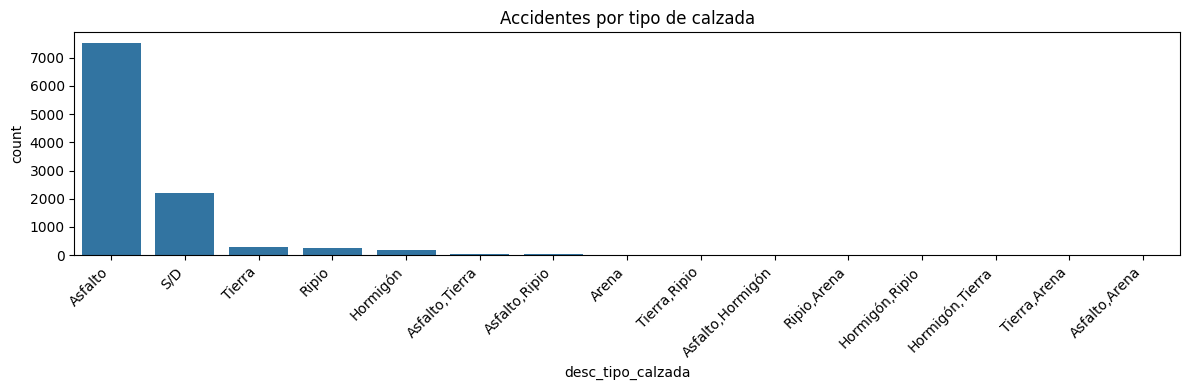

In [33]:
plt.figure(figsize=(12,4))
sns.countplot(data=accidents_df, x="desc_tipo_calzada", order=accidents_df["desc_tipo_calzada"].value_counts().index)
plt.xticks(rotation=45, ha="right")
plt.title("Accidentes por tipo de calzada")
plt.tight_layout()
plt.show()

Como se observa, la gran mayoría de los accidentes se concentra en caminos asfaltados, muy probablemente debido a que gran parte de la provincia cuenta con asfalto en sus vías de transporte\.

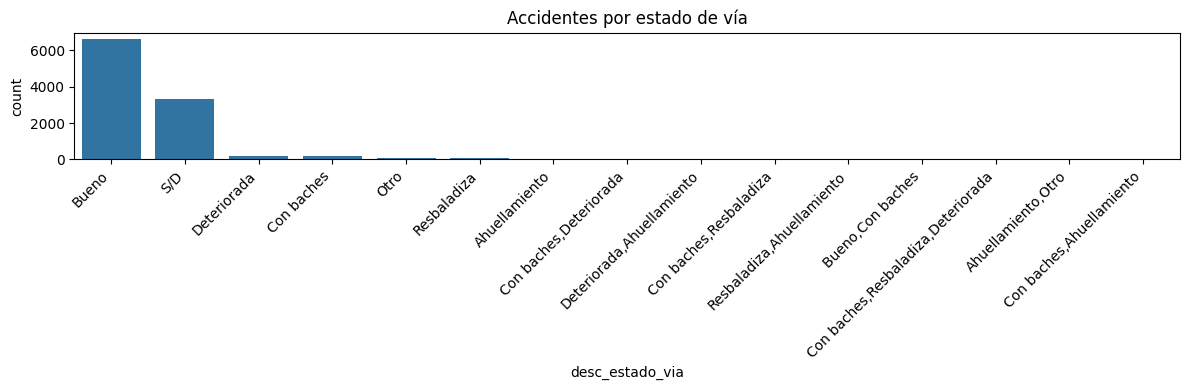

In [34]:
plt.figure(figsize=(12,4))
sns.countplot(data=accidents_df, x="desc_estado_via", order=accidents_df["desc_estado_via"].value_counts().index)
plt.xticks(rotation=45, ha="right")
plt.title("Accidentes por estado de vía")
plt.tight_layout()
plt.show()

Podemos observar que la cantidad de datos faltantes en el estado de vías es significiativa, por lo que no podemos realizar un análisis fiable al respecto

In [35]:
import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 360      
mpl.rcParams["savefig.dpi"] = 600


sns.set_theme(style="whitegrid")

vars_ = ["cant_participantes","total","heridos_leves","heridos_graves","fallecidos","ilesos"]

g = sns.pairplot(
    accidents_df[vars_],
    corner=True,
    height=3.8,  # más grande
    plot_kws={"s": 16, "alpha": 0.35, "edgecolor": "none"},
    diag_kws={"bins": 30}
)

g.fig.suptitle("Pairplot (subset numérico)", y=1.02, fontsize=16)
plt.show()

### Mapa de calor \- Relación entre variables

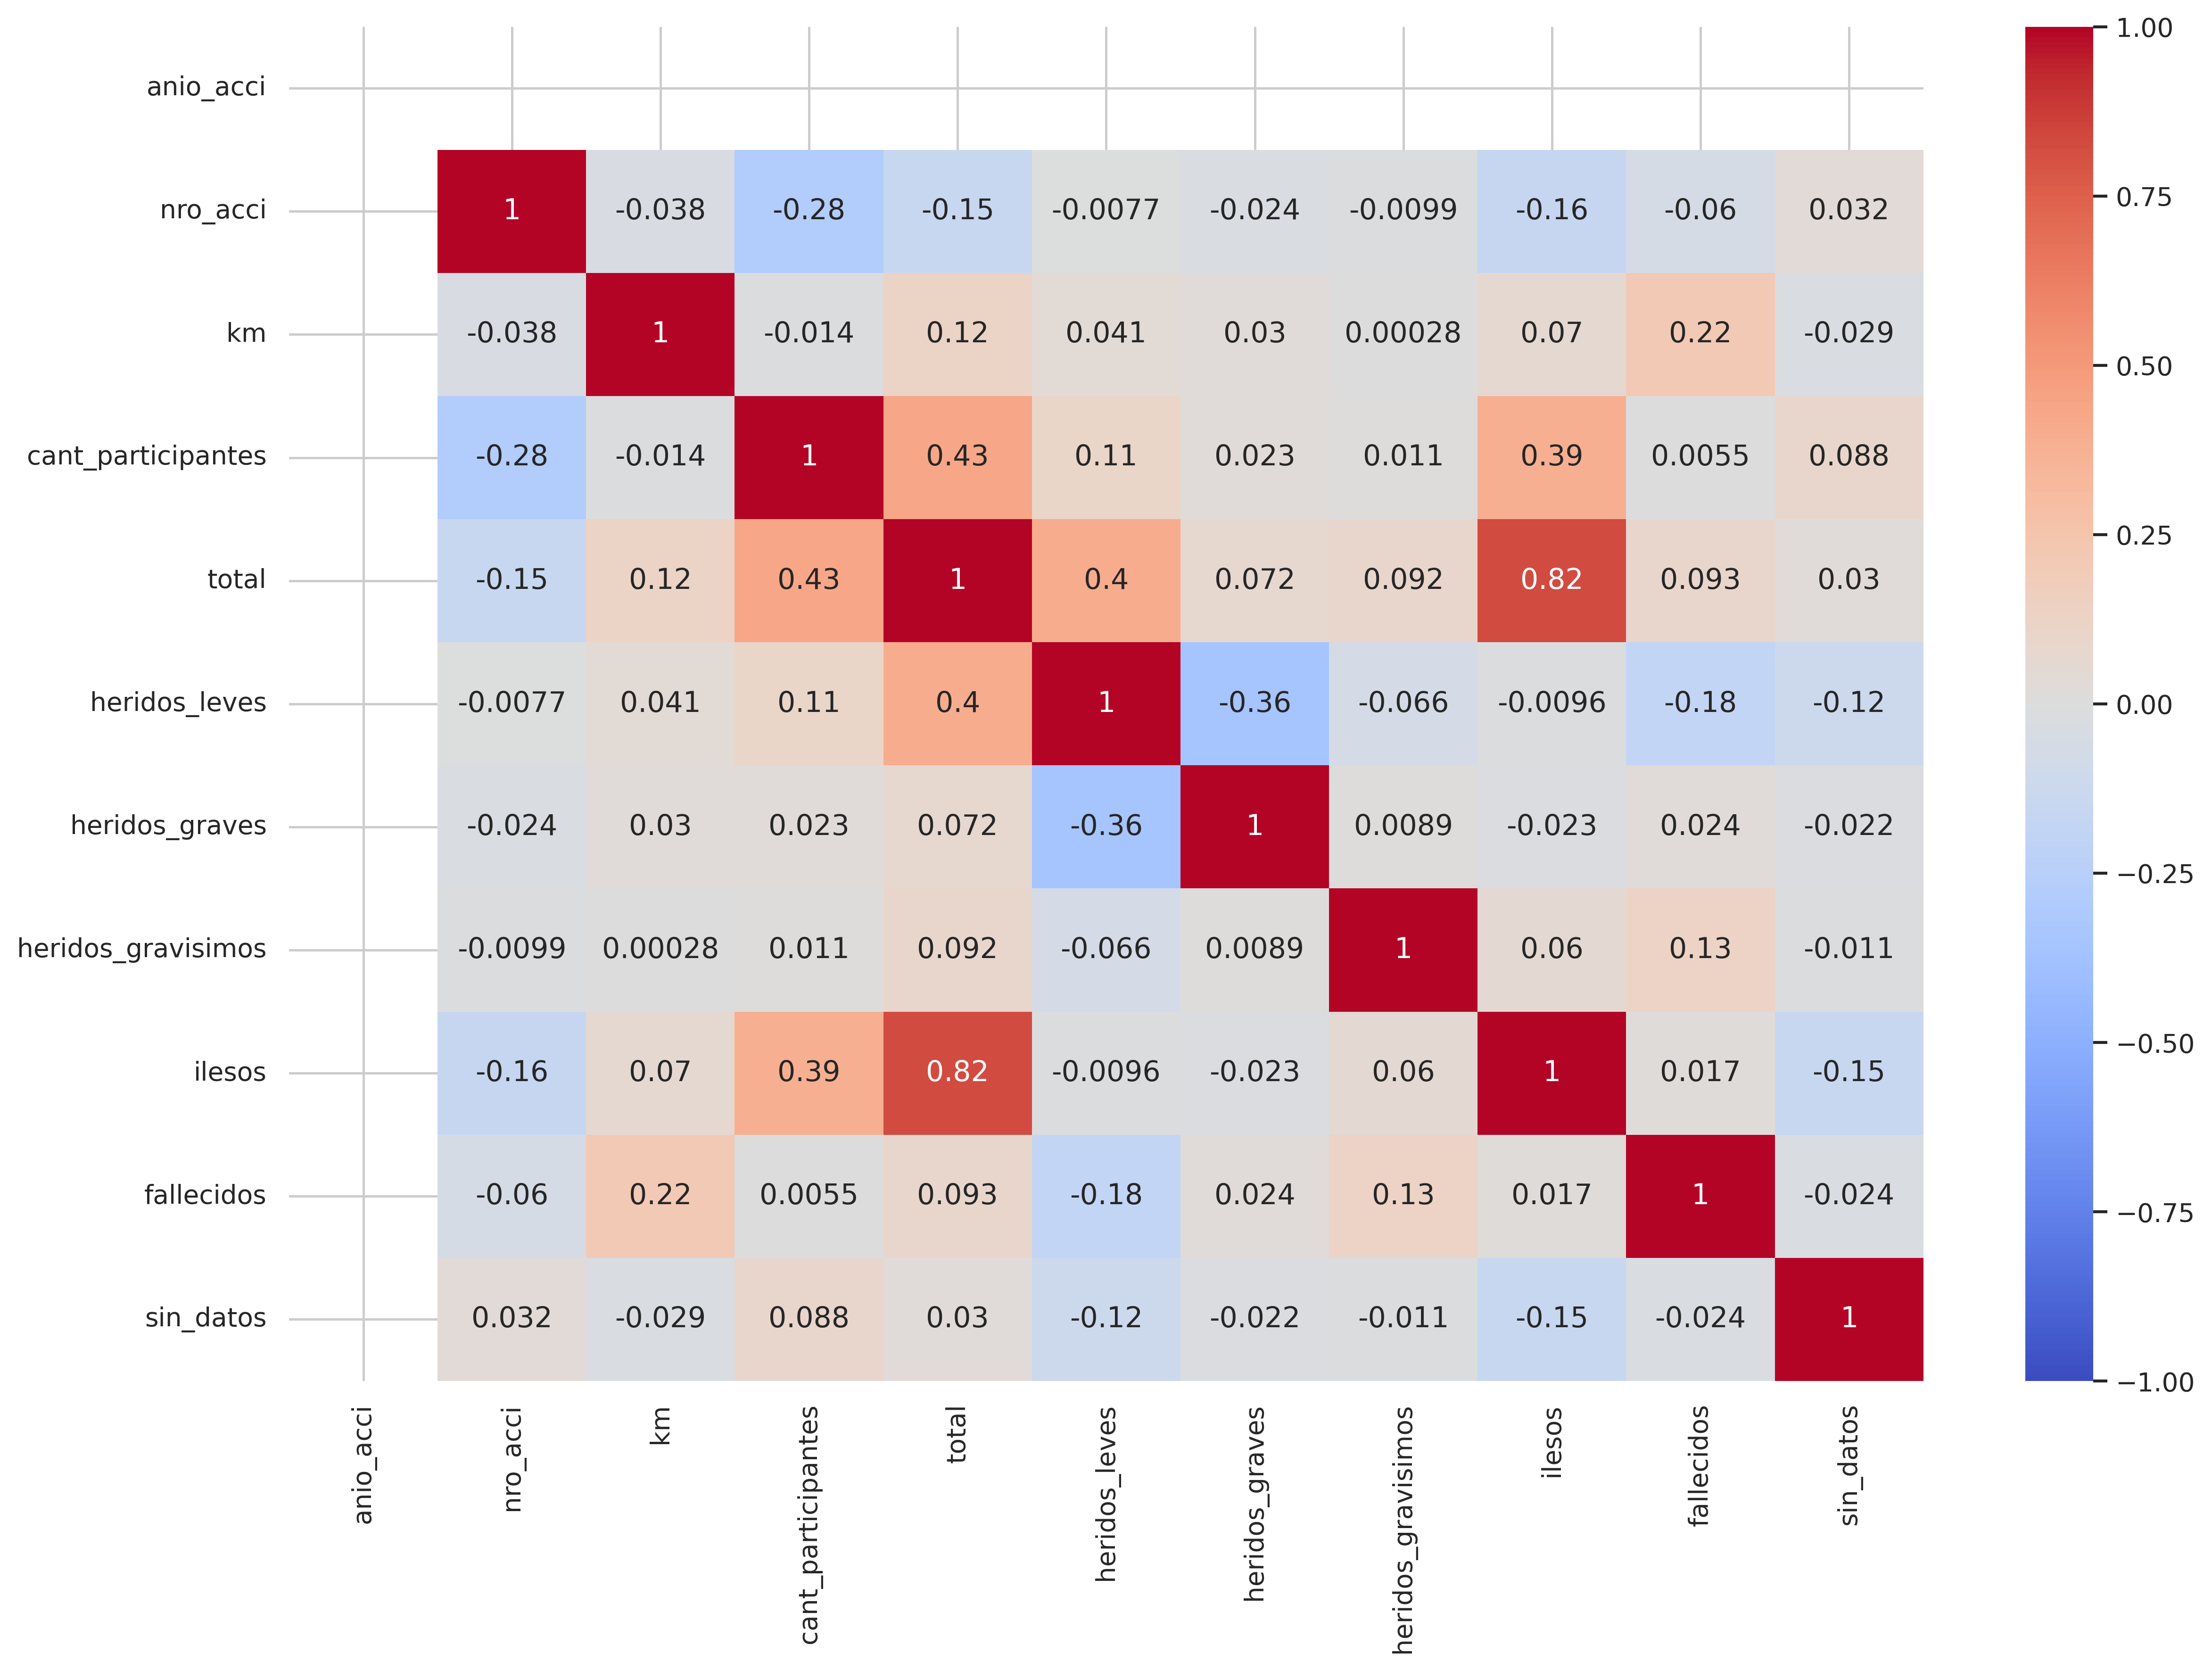

In [36]:

plt.figure(figsize=(14, 10)) 
sns.heatmap(accidents_df.select_dtypes(include='number').corr(), cmap="coolwarm", annot=True,vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

No se observa un nivel de correlación entre variables numéricas independientes relevantes\. La cantidad de ilesos, fallecidos y heridos de todo tipo, contribuyen en la columna "total", por lo que podemos inferir que no se puede realizar una predicción utilizando una combinación de estas variables\. El resto de las variables no presenta un grado de correlación relevante o interesante\.

In [37]:
componentes = (
    accidents_df["ilesos"]
    + accidents_df["heridos_leves"]
    + accidents_df["heridos_graves"]
    + accidents_df["heridos_gravisimos"]
    + accidents_df["fallecidos"]
    + accidents_df["sin_datos"]
)

((accidents_df["total"] == componentes).mean(), (accidents_df["total"] - componentes).value_counts().head())

(1.0,
 0    10581
 Name: count, dtype: int64)

En este análisis podemos ver que la suma de cantidades de ilesos, heridos, fallecidos e involucrados sin datos corresponde al total de involucrados en los accidentes, por lo que trabajar en un análisis predictivo con estas variables numéricas resultaría contraproducente\.

## Conclusión grupal: Elección del dataset

Luego de integrar y evaluar los tres EDA, decidimos continuar el desarrollo del trabajo integrador utilizando el dataset de Recorridos Ecobici 2024\. Nuestra se fundamenta en los siguientes puntos:

- Al ser residentes de CABA, el dataset nos resuelta de gran relevancia cotidiana\. Entender cómo se mueve nuestra propia ciudad nos permite validar los datos con nuestra experiencia en el territorio\.

- Al ser también usuarios frecuentes del servicio Ecobici, este conocimiento previo nos facilita la formulación de hipótesis, la identificación de posibles errores en los datos y el descubrimiento de patrones de uso que para un analista externo podrían pasar desapercibidos\. 

- Consideramos que los hallazgos de este análisis tienen un potencial de aplicación directa\. El proyecto podría derivar en una propuesta de optimización de recursos para el GCBA, ayudando a identificar estaciones críticas, horarios de mayor demanda y necesidades de infraestructura en la red de ciclovías\.

- El dataset de Ecobici 2024 ofrece una muestra robusta \(más de 3\.5 millones de registros en el original\) y una gran variedad de variables \(temporales, geográficas y de usuario\)\. Esto nos garantiza un insumo de gran calidad para aplicar técnicas de análisis más avanzado, modelos predictivos o visualizaciones geoespaciales complejas en las próximas etapas de la materia\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=800c1429-609e-4123-9f1e-fc567ef045a7' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>